# Credit risk: EDA and cleaning

About 32.6k funded consumer loans. Target is `loan_status`, where 1 means defaulted.

I only do fixes that work one row at a time here: drop duplicates, null impossible values.
Imputing and scaling learn a statistic, and run now they'd learn it from rows that end up
in my test set. Those go after the split, inside a Pipeline, so this notebook leaves the
missing values in.

## 1. Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

RAW = "credit_risk_dataset.csv"
df = pd.read_csv(RAW)

print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

32,581 rows x 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
pd.DataFrame({
    "dtype":   df.dtypes,
    "n_null":  df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})

,dtype,n_null,pct_null,n_unique
person_age,int64,0,0.00,58
person_income,int64,0,0.00,4295
person_home_ownership,str,0,0.00,4
person_emp_length,float64,895,2.75,36
loan_intent,str,0,0.00,6
loan_grade,str,0,0.00,7
loan_amnt,int64,0,0.00,753
loan_int_rate,float64,3116,9.56,348
loan_status,int64,0,0.00,2
loan_percent_income,float64,0,0.00,77


## 2. Class balance

This number decides which metrics I can use.

In [3]:
counts = df["loan_status"].value_counts().sort_index()
base_rate = df["loan_status"].mean()

print(counts.to_string())
print(f"\ndefault rate = {base_rate:.4f}  ({base_rate*100:.1f}%)")
print(f"majority-class ('never defaults') accuracy = {1 - base_rate:.4f}")

loan_status
0    25473
1     7108

default rate = 0.2182  (21.8%)
majority-class ('never defaults') accuracy = 0.7818


Predict "no default" for all 32,581 loans and you score 78.2% accuracy while approving
every defaulter. So accuracy is out.

AUC-ROC instead: the chance the model ranks a random defaulter above a random
non-defaulter. Plus PR-AUC, whose floor is the base rate of 0.218, so it's harder to fake
when positives are rare. Neither replaces the cost-based threshold I pick later.

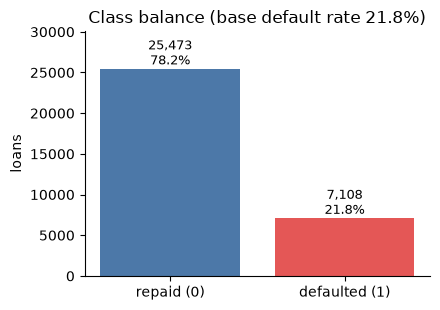

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.bar(["repaid (0)", "defaulted (1)"], counts.values, color=["#4C78A8", "#E45756"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n{v/len(df)*100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("loans")
ax.set_title(f"Class balance (base default rate {base_rate:.1%})")
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Missing values

Two columns have gaps. Check first whether rows with a missing value default at a different
rate, because if they do, the gap is itself a signal and imputing over it throws that away.

In [5]:
rows = []
for col in ["person_emp_length", "loan_int_rate"]:
    miss = df[col].isna()
    rows.append({
        "column": col,
        "n_missing": int(miss.sum()),
        "pct_missing": round(miss.mean() * 100, 2),
        "default_rate_when_missing": round(df.loc[miss,  "loan_status"].mean(), 4),
        "default_rate_when_present": round(df.loc[~miss, "loan_status"].mean(), 4),
    })

miss_tbl = pd.DataFrame(rows)
miss_tbl["gap_vs_base"] = (miss_tbl["default_rate_when_missing"] - base_rate).round(4)
miss_tbl

,column,n_missing,pct_missing,default_rate_when_missing,default_rate_when_present,gap_vs_base
0,person_emp_length,895,2.75,0.3151,0.2154,0.0969
1,loan_int_rate,3116,9.56,0.2067,0.2194,-0.0115


`person_emp_length` missing rows default at 31.5% against a 21.8% base, so a blank
employment history is itself a risk signal. `loan_int_rate` shows nothing much, 20.7%
against 21.9%.

That splits my preprocessing, though in the next notebook rather than this one. Logistic
regression can't accept a NaN at all, so it gets `SimpleImputer(add_indicator=True)` from
`sklearn.impute`: that fills each gap with the training median and adds a 0/1 column
recording which rows were blank to begin with, so the signal survives the fill.
`HistGradientBoostingClassifier` needs neither, because it learns at each split which
direction to send missing values. Both live in the Pipeline, after the split.

## 4. Duplicate rows

If the same row appears twice and the split puts one copy in train and the other in test,
the model gets graded on a row it memorised. These have to go before `train_test_split`.

In [6]:
n_dupe = df.duplicated().sum()
dupe_rows = df[df.duplicated(keep=False)]

print(f"exact duplicate rows (2nd+ copy): {n_dupe}")
print(f"rows involved in any duplication: {len(dupe_rows)}")
print(f"default rate among duplicated rows: {dupe_rows['loan_status'].mean():.4f}  (base {base_rate:.4f})")

dupe_rows.sort_values(list(df.columns)).head(6)

exact duplicate rows (2nd+ copy): 165
rows involved in any duplication: 330
default rate among duplicated rows: 0.1152  (base 0.2182)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
17601,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2


They match on all 12 columns including the target. With no loan ID I can't separate a
double-entered loan from two people agreeing on every field, but at 12 columns wide that's
unlikely. 165 rows out of 32,581 is cheaper than risking the leak.

## 5. Impossible and extreme values

Age 144 and 123 years of employment are data entry errors, so the value is wrong. A \$6M
income is unusual but real. Only the first kind gets touched.

In [7]:
print("--- age over 100 ---")
print(df.loc[df["person_age"] > 100,
             ["person_age", "person_emp_length", "person_income", "loan_status"]].to_string())

print("\n--- employment length over 100 years ---")
print(df.loc[df["person_emp_length"] > 100,
             ["person_age", "person_emp_length", "person_income", "loan_status"]].to_string())

--- age over 100 ---
       person_age  person_emp_length  person_income  loan_status
81            144                4.0         250000            0
183           144                4.0         200000            0
575           123                2.0          80004            0
747           123                7.0          78000            0
32297         144               12.0        6000000            0

--- employment length over 100 years ---
     person_age  person_emp_length  person_income  loan_status
0            22              123.0          59000            1
210          21              123.0         192000            0


In [8]:
# Softer contradiction: more years employed than years alive-and-of-working-age.
impossible_emp = df["person_emp_length"] > (df["person_age"] - 16)

print(f"rows where emp_length > age - 16: {impossible_emp.sum():,} "
      f"({impossible_emp.mean()*100:.1f}% of data)")
print(f"default rate among them: {df.loc[impossible_emp, 'loan_status'].mean():.4f} "
      f"(base {base_rate:.4f})")
print()
print(df.loc[impossible_emp, ["person_age", "person_emp_length"]]
        .value_counts().head(8).to_string())

rows where emp_length > age - 16: 740 (2.3% of data)
default rate among them: 0.2027 (base 0.2182)

person_age  person_emp_length
22          7.0                  160
23          8.0                  129
24          9.0                   97
21          6.0                   64
26          11.0                  51
28          13.0                  48
27          12.0                  44
25          10.0                  43


740 rows (2.3%) claim more employment years than they plausibly could, but most are mild:
a 21-year-old reporting 6 years rather than an impossible 123. Their default rate sits near
the base rate.

I'm keeping them, since dropping 2.3% of the data on a heuristic costs more than the noise
does. The flagrant ones, age over 100 and employment over 100, get the offending cell set
to NaN, leaving the other 11 fields usable.

This goes in the README limitations.

In [9]:
num_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
            "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]

df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.73,6.35,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.85,61983.12,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.79,4.14,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.37,6322.09,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.01,3.24,5.42,7.90,10.99,13.47,23.22
loan_percent_income,32581.0,0.17,0.11,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.80,4.06,2.00,3.00,4.00,8.00,30.00


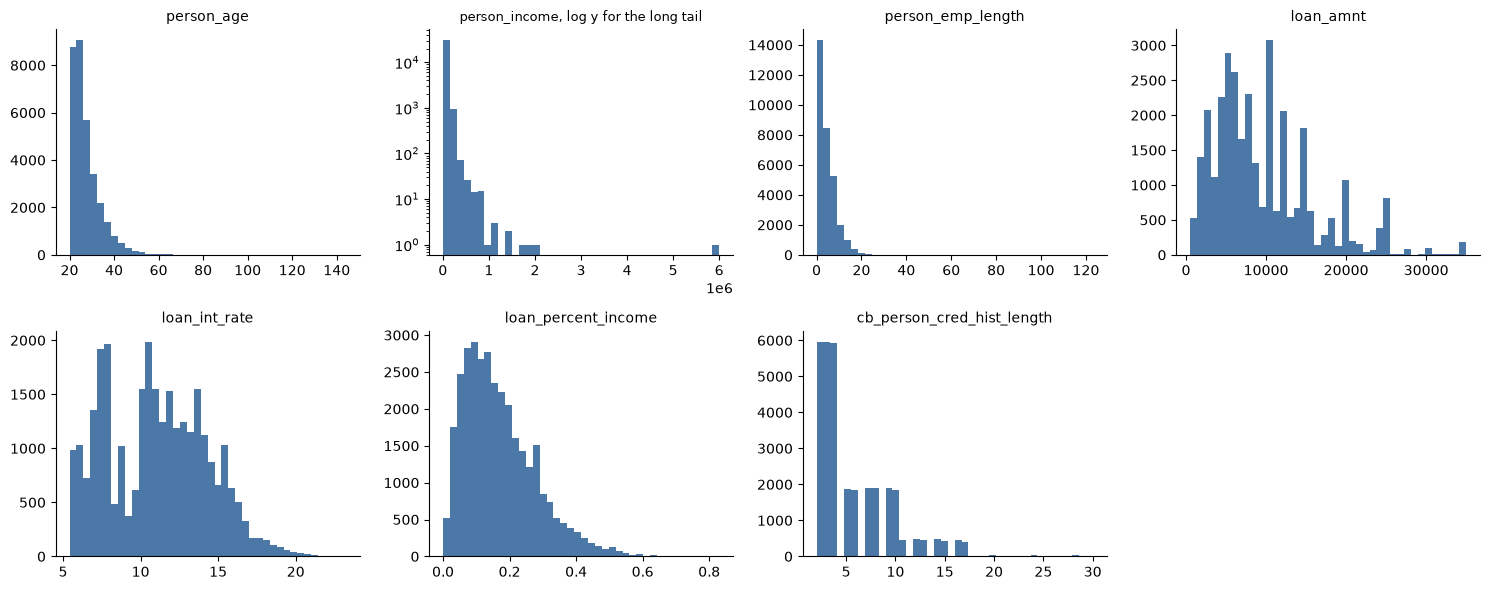

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df[col].dropna(), bins=40, color="#4C78A8")
    ax.set_title(col, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    if col == "person_income":
        ax.set_yscale("log")
        ax.set_title("person_income, log y for the long tail", fontsize=9)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

`person_income` has a long right tail, max \$6M against a \$66k mean. That skew matters for
logistic regression, which wants a roughly linear relationship on the log-odds scale, and
not for trees. If I fix it, it's a log transform inside the logistic regression pipeline after the split.

## 6. Categorical features

`loan_grade` and `loan_int_rate` aren't applicant facts. They're the lender's own risk
assessment, assigned at origination, so using them means partly predicting another model's
output. Here's how strong they are.

In [11]:
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

for col in cat_cols:
    tbl = (df.groupby(col)["loan_status"]
             .agg(n="size", default_rate="mean")
             .sort_values("default_rate", ascending=False))
    tbl["default_rate"] = tbl["default_rate"].round(4)
    tbl["lift_vs_base"] = (tbl["default_rate"] / base_rate).round(2)
    print(f"--- {col} ---")
    print(tbl.to_string())
    print()

--- person_home_ownership ---
                           n  default_rate  lift_vs_base
person_home_ownership                                   
RENT                   16446        0.3157          1.45
OTHER                    107        0.3084          1.41
MORTGAGE               13444        0.1257          0.58
OWN                     2584        0.0747          0.34

--- loan_intent ---
                      n  default_rate  lift_vs_base
loan_intent                                        
DEBTCONSOLIDATION  5212        0.2859          1.31
MEDICAL            6071        0.2670          1.22
HOMEIMPROVEMENT    3605        0.2610          1.20
PERSONAL           5521        0.1989          0.91
EDUCATION          6453        0.1722          0.79
VENTURE            5719        0.1481          0.68

--- loan_grade ---
                n  default_rate  lift_vs_base
loan_grade                                   
G              64        0.9844          4.51
F             241        0.7054  

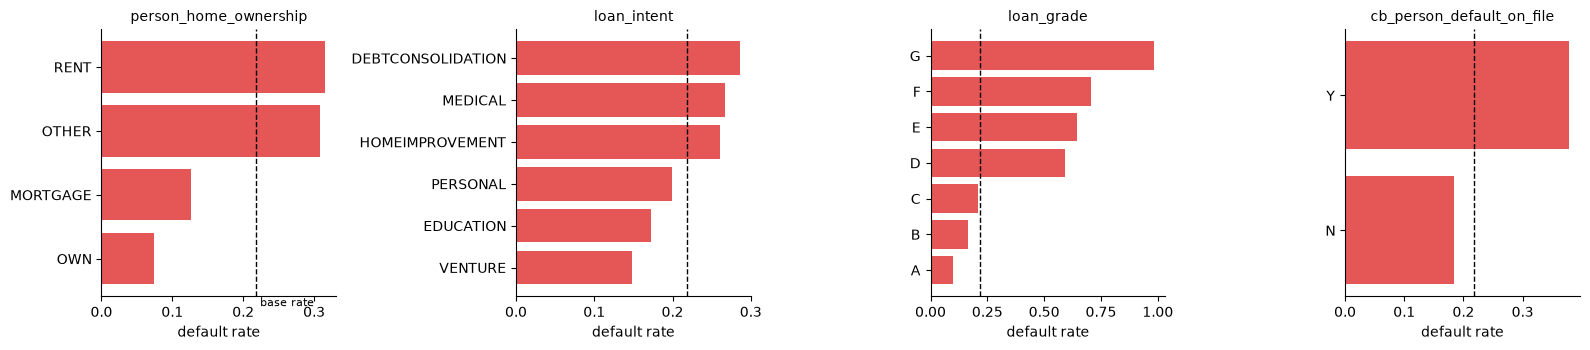

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, col in zip(axes, cat_cols):
    r = df.groupby(col)["loan_status"].mean().sort_values()
    ax.barh(r.index.astype(str), r.values, color="#E45756")
    ax.axvline(base_rate, ls="--", lw=1, color="black")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("default rate")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].text(base_rate, -0.6, " base rate", fontsize=8, va="top")
plt.tight_layout()
plt.show()

`loan_grade` runs from 10% default at A to 98% at G, so grade G is nearly a label saying
the loan defaulted.

It isn't textbook leakage, since the grade is known at approval time. But a model leaning
on it answers "what did the underwriter think" rather than "will this borrower repay".

Both columns stay in the file. I run the pipeline twice at modelling time, with and without
them, and report both AUCs.

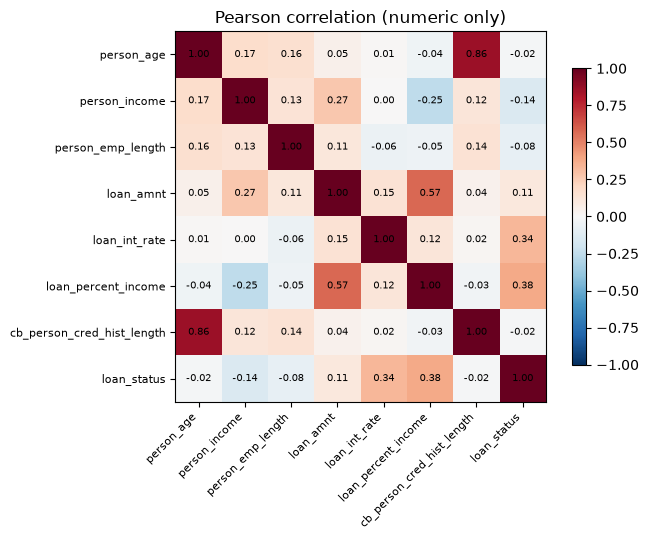

In [13]:
# Correlation among numeric features, to spot redundancy before reading SHAP later.
corr = df[num_cols + ["loan_status"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Pearson correlation (numeric only)")
plt.tight_layout()
plt.show()

`loan_percent_income` is `loan_amnt / person_income` by construction, so of course it
tracks both parents. Neither model breaks on correlated inputs, but it matters when I read
SHAP later, since correlated features split importance between themselves.

## 7. Apply the cleaning

Every rule below depends only on values inside a single row, never on a statistic across
the dataset. That's what makes it safe to run before the split.

In [14]:
clean = df.copy()
log = []

# 1. Drop exact duplicates so the same row can't land in both train and test.
before = len(clean)
clean = clean.drop_duplicates().reset_index(drop=True)
log.append(("dropped exact duplicate rows", before - len(clean)))

# 2. Null out impossible ages (keep the rest of the row).
bad_age = clean["person_age"] > 100
clean.loc[bad_age, "person_age"] = np.nan
log.append(("person_age > 100 set to NaN", int(bad_age.sum())))

# 3. Null out impossible employment lengths (keep the rest of the row).
bad_emp = clean["person_emp_length"] > 100
clean.loc[bad_emp, "person_emp_length"] = np.nan
log.append(("person_emp_length > 100 set to NaN", int(bad_emp.sum())))

for label, n in log:
    print(f"{n:>6,}  {label}")

print(f"\n{len(df):,} rows in  ->  {len(clean):,} rows out  "
      f"({len(df) - len(clean):,} removed, {(len(df)-len(clean))/len(df)*100:.2f}%)")

   165  dropped exact duplicate rows
     5  person_age > 100 set to NaN
     2  person_emp_length > 100 set to NaN

32,581 rows in  ->  32,416 rows out  (165 removed, 0.51%)


In [15]:
# person_age became float because of the NaNs; make that explicit rather than accidental.
clean["person_age"] = clean["person_age"].astype("Float64")

print("missing values left in (imputation happens after the split):")
print(clean.isna().sum()[lambda s: s > 0].to_string())

print(f"\ndefault rate: {df['loan_status'].mean():.4f} (raw) -> "
      f"{clean['loan_status'].mean():.4f} (clean)")
print(f"duplicates remaining: {clean.duplicated().sum()}")

missing values left in (imputation happens after the split):
person_age              5
person_emp_length     889
loan_int_rate        3095

default rate: 0.2182 (raw) -> 0.2187 (clean)
duplicates remaining: 0


In [16]:
OUT = "credit_risk_clean.csv"
clean.to_csv(OUT, index=False)
print(f"wrote {OUT}: {len(clean):,} rows x {clean.shape[1]} columns")
clean.head()

wrote credit_risk_clean.csv: 32,416 rows x 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000,RENT,NaN,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21.0,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25.0,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23.0,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24.0,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 8. Summary

Dropped 165 exact duplicates, since a duplicate spanning train and test leaks the answer.
Set 5 impossible ages and 2 impossible employment lengths to NaN, nulling the cell rather
than the row.

The rest is the pipeline's job. Imputing, scaling and encoding have to see training data
only. No SMOTE either, since resampling before the split is the classic leakage bug and
`class_weight="balanced"` does the job. I kept `loan_grade`, `loan_int_rate`, the 740
soft-contradictory employment rows and the high earners.

For the modelling notebook: base rate 21.8%, so AUC-ROC and PR-AUC, never accuracy.
Employment-length missingness predicts default, so logistic regression needs `add_indicator=True` while
HistGB keeps the raw NaN; interest-rate missingness doesn't, so plain imputation is fine.
`loan_grade` needs the with-and-without comparison. No time column exists, so a stratified
random split is correct and the README should say so.

Next: stratified split, then the logistic regression baseline before anything fancier.